In [1]:
# Step 1: Install required libraries
!pip install -q transformers torch pillow requests matplotlib

In [2]:
# Step 2: Import libraries
from transformers import pipeline
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt

In [3]:
# Step 3: Load the pretrained Vision Transformer model
print("Loading Vision Transformer model...")

classifier = pipeline(
    "image-classification",
    model="google/vit-base-patch16-224"
)

print("Model loaded successfully!\n")

Loading Vision Transformer model...



model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

C:\Users\hashe\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\hashe\.cache\huggingface\hub\models--google--vit-base-patch16-224. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 768d0696-93b0-48a7-b553-fa3e2c26561e)')' thrown while requesting HEAD https://huggingface.co/api/resolve-cache/models/google/vit-base-patch16-224/3f49326eb077187dfe1c2a2bb15fbd74e6ab91e3/preprocessor_config.json
Retrying in 1s [Retry 1/5].
Device set to use cpu


Model loaded successfully!



In [6]:
# Step 4: List of image URLs
images = [
    {
        "name": "Cat",
        "url": "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/cats.png",
        "actual": "Cat"
    },
    {
        "name": "Dog",
        "url": "https://images.unsplash.com/photo-1517849845537-4d257902454a?w=600",
        "actual": "Dog"
    },
    {
        "name": "Car",
        "url": "https://images.unsplash.com/photo-1503376780353-7e6692767b70?w=600",
        "actual": "Car"
    },
    {
        "name": "Bird",
        "url": "https://images.unsplash.com/photo-1444464666168-49d633b86797?w=600",
        "actual": "Bird"
    },
   
]


Image 1


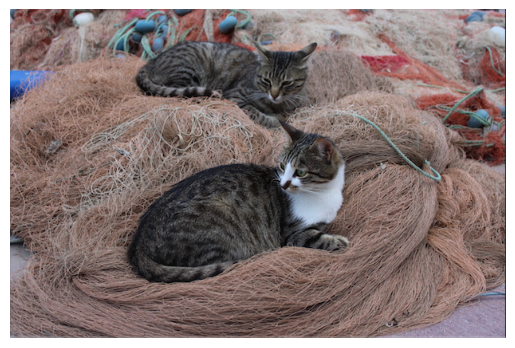

Actual Object     : Cat
Predicted Class   : tabby, tabby cat
Confidence Score  : 27.69%
Prediction Status : Correct
Image 2


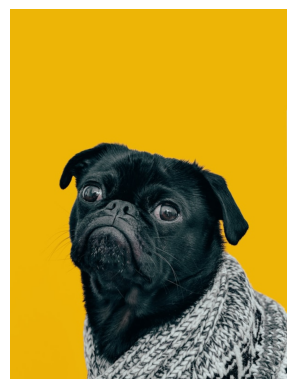

Actual Object     : Dog
Predicted Class   : pug, pug-dog
Confidence Score  : 71.60%
Prediction Status : Correct
Image 3


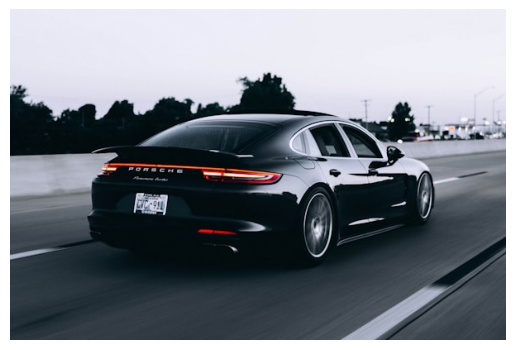

Actual Object     : Car
Predicted Class   : sports car, sport car
Confidence Score  : 24.80%
Prediction Status : Correct
Image 4


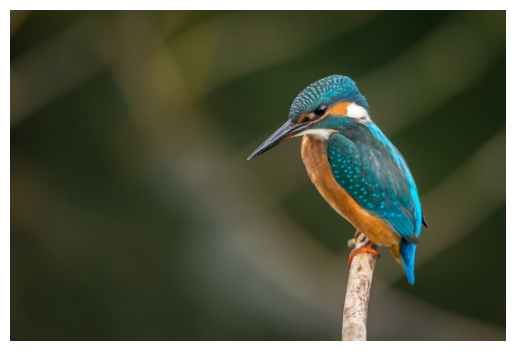

Actual Object     : Bird
Predicted Class   : jacamar
Confidence Score  : 83.14%
Prediction Status : May differ (Model predicted a specific category)


In [7]:
# Step 5: Predict each image

for i, item in enumerate(images, start=1):

    print("="*70)
    print(f"Image {i}")

    response = requests.get(item["url"])
    image = Image.open(BytesIO(response.content)).convert("RGB")

    plt.imshow(image)
    plt.axis("off")
    plt.show()

    prediction = classifier(image)

    predicted_class = prediction[0]["label"]
    confidence = prediction[0]["score"]

    print("Actual Object     :", item["actual"])
    print("Predicted Class   :", predicted_class)
    print("Confidence Score  : {:.2%}".format(confidence))

    if item["actual"].lower() in predicted_class.lower():
        print("Prediction Status : Correct")
    else:
        print("Prediction Status : May differ (Model predicted a specific category)")